In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [20]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)

C:\Users\victo\AppData\Local\Temp\ipykernel_12224\4154608675.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


In [21]:
data = data.drop(data[data["position"] == "team"].index) 

In [125]:
(data_game["champion"] + "_picked").values

array(['Jax_picked', 'Xin Zhao_picked', 'Sylas_picked', 'Caitlyn_picked',
       'Karma_picked'], dtype=object)

In [ ]:
pick_set = []
ban_set = []
for i in tqdm(range(0,len(data),5)):
    data_game = data.iloc[i:i+5]
    pick_set_game = []
    ban_set_game = []
    champs_in_game = data_game["champion"]
    if (data_game["ban1"].hasnans == False): #Some bans are missing for some games, these are assumed to be as a result of a team using all their time and missing the opputunity to ban and as such the game can sstill be kept
        ban_set_game.append(data_game.iloc[0]["ban1"]+"_banned")
    if (data_game["ban2"].hasnans == False):
        ban_set_game.append(data_game.iloc[0]["ban2"]+"_banned")
    if (data_game["ban3"].hasnans == False):
        ban_set_game.append(data_game.iloc[0]["ban3"]+"_banned")
    if (data_game["ban4"].hasnans == False):
        ban_set_game.append(data_game.iloc[0]["ban4"]+"_banned")
    if (data_game["ban5"].hasnans == False):
        ban_set_game.append(data_game.iloc[0]["ban5"]+"_banned")
    for champ in champs_in_game:
        champ_name = champ + "_picked"
        pick_set_game.append(champ_name)
    pick_set.append(pick_set_game)
    ban_set.append(np.unique(ban_set_game))






  0%|          | 0/20106 [00:00<?, ?it/s]

In [103]:
data_game.iloc[0][["ban1", "ban2","ban3","ban4","ban5"]] + "_banned"

ban1       Jayce_banned
ban2      Rumble_banned
ban3     Orianna_banned
ban4    Nocturne_banned
ban5      Aurora_banned
Name: 120629, dtype: object

In [175]:
pick_set = []
ban_set = []
result = []
for i in tqdm(range(0,len(data),5)):
    data_game = data.iloc[i:i+5]
    picked = (data_game["champion"] + "_picked").values
    picked = picked[~pd.isnull(picked)]
    banned = (data_game.iloc[0][["ban1", "ban2","ban3","ban4","ban5"]] + "_banned").values
    banned = banned[~pd.isnull(banned)]
    pick_set.append(picked)
    ban_set.append(banned)
    result.append(data_game.iloc[0]["result"])


  0%|          | 0/20106 [00:00<?, ?it/s]

In [24]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(pick_set).transform(pick_set)
df_ap = pd.DataFrame(te_ary, columns=te.columns_)

In [25]:
df_ap

,Aatrox_picked,Ahri_picked,Akali_picked,Akshan_picked,Alistar_picked,Ambessa_picked,Amumu_picked,Anivia_picked,Annie_picked,Aphelios_picked,...,Yunara_picked,Yuumi_picked,Zaahen_picked,Zac_picked,Zed_picked,Zeri_picked,Ziggs_picked,Zilean_picked,Zoe_picked,Zyra_picked
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20102,False,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
20103,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20104,True,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [26]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_ap, min_support=0.01,use_colnames=True)

We need to use a very low support to get sets of a size greater than 1 since there are only ever 5 champions and very many combinations of them.

In [27]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

In [28]:
freq_greater_1 = frequent_itemsets[(frequent_itemsets['length'])>1]

In [29]:
freq_greater_1.sort_values(by=["support"])

,support,itemsets,length
88,0.010047,"(Ambessa_picked, Ahri_picked)",2
170,0.010047,"(K'Sante_picked, Nautilus_picked)",2
196,0.010096,"(Rakan_picked, Orianna_picked)",2
188,0.010146,"(Maokai_picked, Rell_picked)",2
195,0.010146,"(Nocturne_picked, Orianna_picked)",2
...,...,...,...
208,0.020790,"(Rumble_picked, Rell_picked)",2
153,0.022481,"(Leona_picked, Ezreal_picked)",2
212,0.022879,"(Varus_picked, Rell_picked)",2
145,0.024072,"(Rell_picked, Corki_picked)",2


Xayah and Rakan are a typical combo so seeing them with the highest support is good

In [30]:
from mlxtend.frequent_patterns import fpgrowth

In [31]:
frequent_itemsets_fpg = fpgrowth(df_ap, min_support=0.01,use_colnames=True)

In [32]:
frequent_itemsets_fpg['length'] = frequent_itemsets_fpg['itemsets'].apply(lambda x: len(x))
freq_greater_1_fpg = frequent_itemsets_fpg[(frequent_itemsets_fpg['length'])>1]
freq_greater_1_fpg.sort_values(by=["support"])

,support,itemsets,length
123,0.010047,"(K'Sante_picked, Nautilus_picked)",2
184,0.010047,"(Ambessa_picked, Ahri_picked)",2
100,0.010096,"(Rakan_picked, Orianna_picked)",2
93,0.010146,"(Maokai_picked, Rell_picked)",2
166,0.010146,"(Varus_picked, Viktor_picked)",2
...,...,...,...
192,0.020790,"(Rumble_picked, Rell_picked)",2
89,0.022481,"(Leona_picked, Ezreal_picked)",2
96,0.022879,"(Varus_picked, Rell_picked)",2
126,0.024072,"(Rell_picked, Corki_picked)",2


In [179]:
data.shape

(100530, 165)

In [178]:
pick_ban_set = [] # First is champ selected, second is ban
for i in range(len(pick_set)):
    pick_ban_set.append(np.concat([pick_set[i],ban_set[i]]))

In [131]:
ban_set[163]

array(['Skarner_banned', 'Nocturne_banned', 'Ashe_banned', 'Varus_banned'],
      dtype=object)

In [180]:
te = TransactionEncoder()
te_ary = te.fit(pick_ban_set).transform(pick_ban_set)
df_ap_pb = pd.DataFrame(te_ary, columns=te.columns_)

In [202]:
frequent_itemsets_pb = fpgrowth(df_ap_pb, min_support=0.01,use_colnames=True)
frequent_itemsets_pb['length'] = frequent_itemsets_pb['itemsets'].apply(lambda x: len(x))
freq_greater_1_pb = frequent_itemsets_pb#[(frequent_itemsets_pb['length'])>1]
freq_greater_1_pb.sort_values(by=["support"])

,support,itemsets,length
807,0.010047,"(Jayce_banned, Pantheon_picked)",2
139,0.010047,(Pyke_picked),1
555,0.010047,"(Varus_banned, Maokai_banned)",2
541,0.010047,"(Ambessa_picked, Ahri_picked)",2
686,0.010047,"(Kai'Sa_banned, Gwen_banned)",2
...,...,...,...
88,0.154780,(Azir_banned),1
52,0.155625,(Rumble_banned),1
85,0.177360,(Gwen_banned),1
0,0.178852,(Vi_banned),1


In [203]:
common_pick_ban = freq_greater_1_pb.sort_values(by=["support"])
common_pick_ban

,support,itemsets,length
807,0.010047,"(Jayce_banned, Pantheon_picked)",2
139,0.010047,(Pyke_picked),1
555,0.010047,"(Varus_banned, Maokai_banned)",2
541,0.010047,"(Ambessa_picked, Ahri_picked)",2
686,0.010047,"(Kai'Sa_banned, Gwen_banned)",2
...,...,...,...
88,0.154780,(Azir_banned),1
52,0.155625,(Rumble_banned),1
85,0.177360,(Gwen_banned),1
0,0.178852,(Vi_banned),1


In [204]:
norms = []
for pick_ban_index in range(len(common_pick_ban)):
    k = 1
    for i in common_pick_ban.iloc[pick_ban_index]["itemsets"]:
        k = k * frequent_itemsets_pb[frequent_itemsets_pb["itemsets"]==set([i])]["support"].iloc[0]
    norm_support = common_pick_ban.iloc[pick_ban_index]["support"] / k
    norms.append(norm_support)
common_pick_ban["norm_support"] = norms

In [205]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(common_pick_ban.sort_values(by=["norm_support"]))

      support                               itemsets  length  norm_support
307  0.011340          (Azir_banned, Kalista_banned)       2      0.550677
577  0.010096            (Azir_banned, Jayce_banned)       2      0.557391
255  0.010892          (Aurora_banned, Varus_banned)       2      0.626520
878  0.014175       (Pantheon_banned, Rumble_banned)       2      0.628026
469  0.010892          (Azir_banned, Ambessa_banned)       2      0.644021
827  0.012136         (Orianna_banned, Varus_banned)       2      0.651528
841  0.011788          (Orianna_banned, Gwen_banned)       2      0.674541
751  0.010445       (Kalista_banned, Taliyah_banned)       2      0.680938
261  0.011141           (Aurora_banned, Gwen_banned)       2      0.683055
466  0.010196       (Ambessa_banned, Kalista_banned)       2      0.701335
182  0.013827         (Varus_banned, Skarner_banned)       2      0.704612
253  0.011837             (Aurora_banned, Vi_banned)       2      0.719691
564  0.018900            

In [219]:
print(common_pick_ban[common_pick_ban["itemsets"] == set(["Kalista_banned"])]["support"].iloc[0])
print(common_pick_ban[common_pick_ban["itemsets"] == set(["Azir_banned"])]["support"].iloc[0])
t = common_pick_ban[common_pick_ban["itemsets"] == set(["Kalista_banned"])]["support"].iloc[0] * common_pick_ban[common_pick_ban["itemsets"] == set(["Azir_banned"])]["support"].iloc[0]
t

0.13304486223018006
0.1547796677608674


np.float64(0.020592639573277647)

In [217]:
k = common_pick_ban[common_pick_ban["itemsets"] == set(["Azir_banned", "Kalista_banned"])]["support"].iloc[0]
k

np.float64(0.011339898537749925)

In [218]:
k / t

np.float64(0.550677269778728)

In [224]:
wins = []
totals = []
winrate = []
for i in tqdm(range(len(common_pick_ban))):
    win = 0.0
    
    total = 0.0
    itemsets = common_pick_ban.iloc[i]["itemsets"]
    for game_index in range(len(pick_ban_set)):
        if set(itemsets).intersection(set(pick_ban_set[game_index])) == set(itemsets):
            win += result[game_index]
            total += 1.0
    wins.append(win)
    totals.append(total)
    winrate.append(win / total)


  0%|          | 0/899 [00:00<?, ?it/s]

In [225]:
common_pick_ban["wr"] = winrate
common_pick_ban["wins"] = wins
common_pick_ban["totals"] = totals

In [226]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(common_pick_ban.sort_values(by=["norm_support"])[:20][["itemsets", "norm_support", "wr", "totals"]])

                             itemsets  norm_support        wr  totals
307     (Azir_banned, Kalista_banned)      0.550677  0.442982   228.0
577       (Azir_banned, Jayce_banned)      0.557391  0.467980   203.0
255     (Aurora_banned, Varus_banned)      0.626520  0.502283   219.0
878  (Pantheon_banned, Rumble_banned)      0.628026  0.417544   285.0
469     (Azir_banned, Ambessa_banned)      0.644021  0.420091   219.0
827    (Orianna_banned, Varus_banned)      0.651528  0.524590   244.0
841     (Orianna_banned, Gwen_banned)      0.674541  0.468354   237.0
751  (Kalista_banned, Taliyah_banned)      0.680938  0.466667   210.0
261      (Aurora_banned, Gwen_banned)      0.683055  0.428571   224.0
466  (Ambessa_banned, Kalista_banned)      0.701335  0.434146   205.0
182    (Varus_banned, Skarner_banned)      0.704612  0.471223   278.0
253        (Aurora_banned, Vi_banned)      0.719691  0.558824   238.0
564       (Poppy_banned, Gwen_banned)      0.736013  0.426316   380.0
241        (Azir_ban

In [70]:
frequent_itemsets_pb[frequent_itemsets_pb["itemsets"]==set([i])]["support"]

25    0.030006
Name: support, dtype: float64

In [223]:
common_pick_ban

,support,itemsets,length,norm_support
807,0.010047,"(Jayce_banned, Pantheon_picked)",2,1.145360
139,0.010047,(Pyke_picked),1,1.000000
555,0.010047,"(Varus_banned, Maokai_banned)",2,0.759425
541,0.010047,"(Ambessa_picked, Ahri_picked)",2,1.026483
686,0.010047,"(Kai'Sa_banned, Gwen_banned)",2,0.915536
...,...,...,...,...
88,0.154780,(Azir_banned),1,1.000000
52,0.155625,(Rumble_banned),1,1.000000
85,0.177360,(Gwen_banned),1,1.000000
0,0.178852,(Vi_banned),1,1.000000


In [231]:
np.mean(common_pick_ban["wr"])

np.float64(0.49208238662489706)

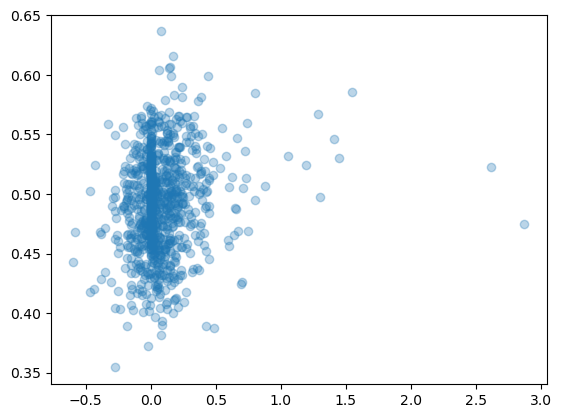

In [232]:
plt.scatter(np.log(common_pick_ban["norm_support"]), common_pick_ban["wr"], alpha=0.3)
plt.show()

In [61]:
norms

[38   NaN
 86   NaN
 Name: support, dtype: float64,
 55   NaN
 67   NaN
 Name: support, dtype: float64,
 30   NaN
 86   NaN
 Name: support, dtype: float64,
 43   NaN
 86   NaN
 Name: support, dtype: float64,
 83   NaN
 89   NaN
 Name: support, dtype: float64,
 25   NaN
 89   NaN
 Name: support, dtype: float64,
 25   NaN
 55   NaN
 Name: support, dtype: float64,
 89    NaN
 144   NaN
 Name: support, dtype: float64,
 5    NaN
 25   NaN
 Name: support, dtype: float64,
 83   NaN
 86   NaN
 Name: support, dtype: float64,
 5    NaN
 83   NaN
 Name: support, dtype: float64,
 25   NaN
 86   NaN
 Name: support, dtype: float64]

In [26]:
0.03797 * 0.030006

0.0011393278199999999

In [30]:
0.001175/0.0011393278199999999

1.031309847239577

In [27]:
print(frequent_itemsets_pb[frequent_itemsets_pb["itemsets"]==set(["Poppy_banned"])]["support"])
frequent_itemsets_pb[frequent_itemsets_pb["itemsets"]==set(["Ambessa_picked"])]["support"]

55    0.029079
Name: support, dtype: float64


67    0.024005
Name: support, dtype: float64

In [29]:
0.001021/(0.029079*0.024005)

1.4626639728149646

Varus is not really a good counter for rumble according to https://u.gg/lol/champions/rumble/counter, though we are seeing Varus appear high so he may just be a high priority ban

In [113]:
te = TransactionEncoder()
te_ary = te.fit(ban_set).transform(ban_set)
df_ap_ban = pd.DataFrame(te_ary, columns=te.columns_)

In [116]:
frequent_itemsets_fpg = fpgrowth(df_ap_ban, min_support=0.1,use_colnames=True)
frequent_itemsets_fpg['length'] = frequent_itemsets_fpg['itemsets'].apply(lambda x: len(x))
#freq_greater_1_fpg = frequent_itemsets_fpg[(frequent_itemsets_fpg['length'])>1]
frequent_itemsets_fpg.sort_values(by=["support"])

,support,itemsets,length
1,0.103800,(Skarner),1
12,0.103850,(Neeko),1
2,0.104049,(Yone),1
4,0.109271,(Ambessa),1
10,0.115289,(Taliyah),1
7,0.117030,(Jayce),1
3,0.133045,(Kalista),1
6,0.144783,(Poppy),1
13,0.145031,(Pantheon),1
11,0.154780,(Azir),1


As expected based on above, Varus is just a high priority ban

Can look more into counter picks (IE make each entry the laners for a given game on opposing sides), seperate by whether the team won or not, add a league or patch to see if a champ is really popular in a certain patch or league (could also seperate those into their own subdatasets). Look at the class roles (Tank, Mage etc), llok more clearly at pick ban, IE make the variables "Varus_picked" and "Varus_banned". Normalize by popularity see above